## Libraries

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Load Data

In [17]:
df = pd.read_csv("compas_two_year_recidivism.csv")

df.shape

(7286, 16)

In [18]:
df.head

<bound method NDFrame.head of       juv_other_count score_text priors_count  juv_misd_count  juvenile_total  \
0                   1        Low          0.0               0             1.0   
1                   0       High          3.0               0             0.0   
2                   0        Low          2.0               0             0.0   
3                   0       High          2.0               0             0.0   
4                   0        Low          1.0               0             0.0   
...               ...        ...          ...             ...             ...   
7281                0     Medium          0.0               0             0.0   
7282                0        Low          3.0               0             0.0   
7283                0        Low          3.0               0             0.0   
7284                0        Low          1.0               0             0.0   
7285                0     Medium          0.0               0             0.0  

## EDA

In [19]:
df.describe()

,juv_other_count,juv_misd_count,juvenile_total,id,two_year_recid,juv_fel_count,age_in_months,age,decile_score
count,7286.000000,7286.000000,7286.000000,7286.000000,7286.000000,7069.000000,7140.000000,7140.000000,7286.000000
mean,0.109662,0.090585,0.265852,5499.579193,0.451139,0.067619,417.203361,34.766947,4.524156
std,0.502209,0.483668,0.950096,3174.414353,0.497641,0.478998,143.352811,11.946068,2.877104
min,0.000000,0.000000,-1.000000,1.000000,0.000000,-1.000000,-36.000000,-3.000000,0.000000
25%,0.000000,0.000000,0.000000,2736.250000,0.000000,0.000000,300.000000,25.000000,2.000000
50%,0.000000,0.000000,0.000000,5507.500000,0.000000,0.000000,372.000000,31.000000,4.000000
75%,0.000000,0.000000,0.000000,8238.500000,1.000000,0.000000,504.000000,42.000000,7.000000
max,17.000000,13.000000,21.000000,11001.000000,1.000000,20.000000,1152.000000,96.000000,23.000000


In [20]:
df.isna().sum()

juv_other_count      0
score_text           0
priors_count       420
juv_misd_count       0
juvenile_total       0
sex                 60
age_cat              0
id                   0
c_charge_degree    233
two_year_recid       0
juv_fel_count      217
age_in_months      146
race                 0
prior_offenses     420
age                146
decile_score         0
dtype: int64

In [ ]:
df.duplicated()

In [21]:
# Retorna um dicionário: {coluna: array_de_categorias}
categorias = {
    col: df[col].dropna().unique()
    for col in df.select_dtypes(include=["object", "category"]).columns
}

for col, vals in categorias.items():
    print(f"{col}: {vals}\n")

score_text: ['Low' 'High' 'Medium' 'low' 'medium' 'LOW' 'MEDIUM' 'HIGH' 'high']

priors_count: ['0.0' '3.0' '2.0' '1.0' '18.0' '16.0' '6.0' '7.0' '-' '4.0' '9.0' '19.0'
 '5.0' '10.0' '13.0' '8.0' '14.0' '17.0' '11.0' '24.0' '25.0' '15.0'
 '12.0' '23.0' '33.0' '20.0' '38.0' '28.0' '250' '26.0' '21.0' '22.0'
 '29.0' '27.0' '31.0' '30.0' '35.0' '36.0' '37.0' '500']

sex: ['Male' 'male' 'female' 'Female' 'MALE' ' Male' 'Female ' '?' 'FEMALE']

age_cat: ['25 - 45' 'Less than 25' 'Greater than 45']

c_charge_degree: ['F' 'M' 'm' 'Misdemeanor' 'Felony' 'f']

race: ['African-American' 'Caucasian' '?' 'Hispanic' 'Other' 'african-american'
 ' African-American' 'HISPANIC' 'caucasian' '-' 'hispanic' 'CAUCASIAN'
 'Native American' ' Caucasian' 'African American' 'AFRICAN-AMERICAN'
 'Asian']

prior_offenses: ['0.0' '3.0' '2.0' '1.0' '18.0' '16.0' '6.0' '7.0' '-' '4.0' '9.0' '19.0'
 '5.0' '10.0' '13.0' '8.0' '14.0' '17.0' '11.0' '24.0' '25.0' '15.0'
 '12.0' '23.0' '33.0' '20.0' '38.0' '28.0' '250' '2

### Uniformizar as categorias das variáveis

In [22]:
# 1. Limpeza básica de espaços em branco nas colunas de texto
cols = ['score_text', 'sex', 'c_charge_degree', 'race']
for col in cols:
  df[col] = df[col].astype(str).str.strip()

# --- score_text ---
# Capitalize padroniza 'LOW', 'low', 'Low' para 'Low'
df['score_text'] = df['score_text'].str.capitalize()

# --- sex ---
# Trata '?' como NaN e padroniza o restante para 'Male'/'Female'
df['sex'] = df['sex'].replace({'?': np.nan})
df['sex'] = df['sex'].str.capitalize()

# --- c_charge_degree ---
# Mapeia siglas 'F'/'M' para os nomes completos (ou mantenha siglas com .upper())
map_charge = {
    'F': 'Felony',
    'f': 'Felony',
    'Felony': 'Felony',
    'M': 'Misdemeanor',
    'm': 'Misdemeanor',
    'Misdemeanor': 'Misdemeanor',
}
df['c_charge_degree'] = df['c_charge_degree'].map(map_charge)

# --- race ---
# 1. Trata '?' e '-' como NaN
df['race'] = df['race'].replace({'-': np.nan})
df['race'] = df['race'].replace({'?': np.nan})

# 2. Padroniza grafia com hífen ('African American' -> 'African-American')
df['race'] = df['race'].replace({'African American': 'African-American'})

# 3. title() deixa cada palavra com inicial maiúscula ('African-American', 'Native American')
df['race'] = df['race'].str.title()

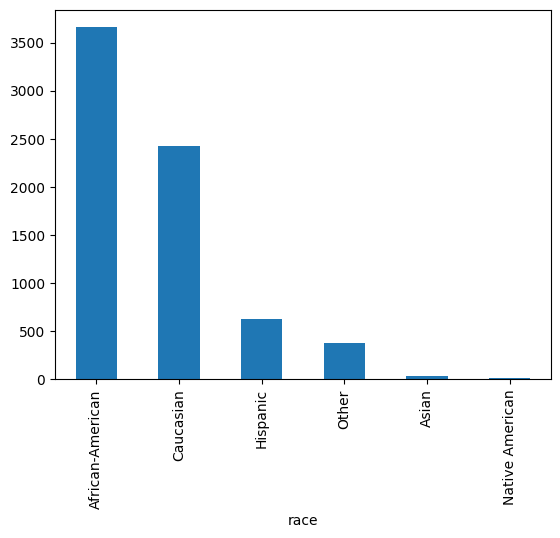

In [23]:
df["race"].value_counts().plot(kind="bar")
plt.show()

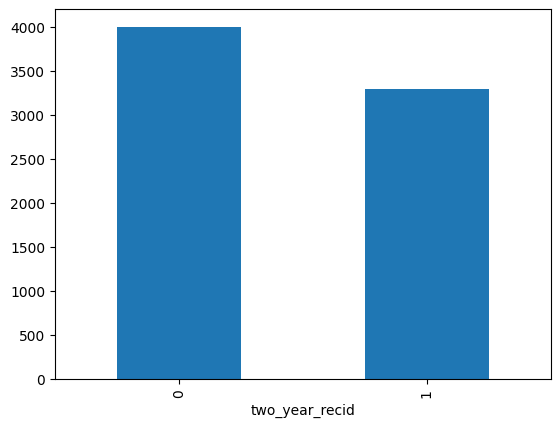

In [24]:
df["two_year_recid"].value_counts().plot(kind="bar")
plt.show()

In [25]:
# Dicionário variável: categorias
categorias = {
    col: df[col].dropna().unique()
    for col in df.select_dtypes(include=["object", "category"]).columns
}

for col, vals in categorias.items():
    print(f"{col}: {vals}\n")

score_text: ['Low' 'High' 'Medium']

priors_count: ['0.0' '3.0' '2.0' '1.0' '18.0' '16.0' '6.0' '7.0' '-' '4.0' '9.0' '19.0'
 '5.0' '10.0' '13.0' '8.0' '14.0' '17.0' '11.0' '24.0' '25.0' '15.0'
 '12.0' '23.0' '33.0' '20.0' '38.0' '28.0' '250' '26.0' '21.0' '22.0'
 '29.0' '27.0' '31.0' '30.0' '35.0' '36.0' '37.0' '500']

sex: ['Male' 'Female' 'Nan']

age_cat: ['25 - 45' 'Less than 25' 'Greater than 45']

c_charge_degree: ['Felony' 'Misdemeanor']

race: ['African-American' 'Caucasian' 'Hispanic' 'Other' 'Native American'
 'Asian']

prior_offenses: ['0.0' '3.0' '2.0' '1.0' '18.0' '16.0' '6.0' '7.0' '-' '4.0' '9.0' '19.0'
 '5.0' '10.0' '13.0' '8.0' '14.0' '17.0' '11.0' '24.0' '25.0' '15.0'
 '12.0' '23.0' '33.0' '20.0' '38.0' '28.0' '250' '26.0' '21.0' '22.0'
 '29.0' '27.0' '31.0' '30.0' '35.0' '36.0' '37.0' '500']



### Outliers

In [26]:
invalid_ages = df[df["age"] < 0]
invalid_ages

,juv_other_count,score_text,priors_count,juv_misd_count,juvenile_total,sex,age_cat,id,c_charge_degree,two_year_recid,juv_fel_count,age_in_months,race,prior_offenses,age,decile_score
2307,0,Medium,3.0,0,0.0,Male,25 - 45,2060,Felony,1,0.0,-36.0,African-American,3.0,-3.0,5
2365,0,High,NaN,0,0.0,Male,Less than 25,5390,Felony,1,0.0,-36.0,African-American,NaN,-3.0,9
3546,0,High,14.0,1,1.0,Male,25 - 45,3023,Felony,1,0.0,-36.0,African-American,14.0,-3.0,9
4123,0,Medium,3.0,0,0.0,Male,25 - 45,2060,Felony,1,0.0,-36.0,African-American,3.0,-3.0,5
4815,0,Medium,0.0,0,0.0,Female,Less than 25,2828,NaN,1,0.0,-36.0,African-American,0.0,-3.0,7


In [27]:
# Filter valid ages
df = df[df['age'] >= 0]

In [28]:
outlier = df[df["priors_count"] == "500"]
outlier

,juv_other_count,score_text,priors_count,juv_misd_count,juvenile_total,sex,age_cat,id,c_charge_degree,two_year_recid,juv_fel_count,age_in_months,race,prior_offenses,age,decile_score
4979,0,Medium,500,0,0.0,Male,25 - 45,4805,Felony,1,0.0,420.0,African-American,500,35.0,7
6321,0,High,500,1,1.0,Male,25 - 45,2899,Felony,1,0.0,360.0,Caucasian,500,30.0,9


In [29]:
outlier = df[df["priors_count"] == "-"]
outlier

,juv_other_count,score_text,priors_count,juv_misd_count,juvenile_total,sex,age_cat,id,c_charge_degree,two_year_recid,juv_fel_count,age_in_months,race,prior_offenses,age,decile_score
19,0,Low,-,0,0.0,Male,Greater than 45,2657,Misdemeanor,0,0.0,588.0,African-American,-,49.0,1
234,0,Low,-,0,0.0,Male,25 - 45,3286,Misdemeanor,1,0.0,480.0,Other,-,40.0,1
335,0,Low,-,0,0.0,Male,25 - 45,9917,Misdemeanor,0,0.0,372.0,African-American,-,31.0,1
346,0,Low,-,0,0.0,Male,Greater than 45,7680,Felony,0,0.0,804.0,Caucasian,-,67.0,1
509,0,High,-,0,0.0,Male,Less than 25,10235,Felony,0,0.0,264.0,African-American,-,22.0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6671,0,Medium,-,0,0.0,Male,25 - 45,3087,Felony,1,0.0,372.0,African-American,-,31.0,7
6907,0,Medium,-,0,1.0,Male,25 - 45,6998,Felony,1,1.0,312.0,Hispanic,-,26.0,5
7005,0,Low,-,0,0.0,Male,Greater than 45,882,Felony,1,0.0,600.0,Caucasian,-,50.0,1
7096,0,Medium,-,0,0.0,Female,Less than 25,6671,Felony,1,0.0,276.0,Caucasian,-,23.0,6


### Remover as observações com 500 priors (outliers) e com "-"

In [30]:
valores_remover = ['500',"-"]  # 3 observações com priores = 500 e 81 observações com "-" priors

df = df[~df['priors_count'].astype(str).str.strip().isin(valores_remover)]

In [31]:
len(df)

7055